In [35]:
import pandas as pd
import numpy as np
import seaborn as sns
import glob
# from upsetplot import from_contents, plot
from matplotlib import pyplot

from pathlib import Path

from dfmodel import DigitalFamilyBinary

from sklearn.metrics import class_likelihood_ratios, recall_score
from sklearn.preprocessing import MinMaxScaler

custom_params = {"axes.spines.right": False, "axes.spines.top": False}
sns.set_theme(context="paper", style="ticks", rc=custom_params, font="Arial", font_scale=1)



In [36]:
bootstrap_columns = [f"target_bootstrap_{n}" for n in range(1000)]

# 30-day Mortality

In [43]:
combined_results = pd.read_csv(
    "design_matrix_test_mortality_risk.tsv",
    sep="\t",
)

outcome_col = "Mortality (30-day) Rate"
label_col = "survival_30_day"
title = "30 Day Mortality"

In [44]:
mort_median = combined_results[outcome_col].mean()
mort_mad = combined_results[outcome_col].std()
mort_mad, mort_median

(0.09401526325702657, 0.06377088235294082)

In [45]:
recall_score(
    combined_results[label_col], np.where(combined_results[outcome_col] > 0.0, 1, 0)
)

0.7976190476190477

In [46]:
cutoffs = [
    max(mort_median - mort_mad, 0),
    mort_median,
    mort_median + mort_mad,
    mort_median + (mort_mad * 2),
    mort_median + (mort_mad * 3),
   # mort_median + (mort_mad * 4),
]

In [47]:
bootstrapped_recalls = []
plr_gp = []
thresholds = []

subsample = combined_results.copy()

for col in bootstrap_columns:

    bootstrapped_recalls.append(
        recall_score(subsample[label_col], np.where(subsample[col] > 0.0, 1, 0))
    )

    for cutoff in cutoffs:

        plr_gp.append(
            class_likelihood_ratios(subsample[label_col], np.where(subsample[col] > cutoff, 1, 0))[0]
        )
        thresholds.append(cutoff)



mort_lr_df = pd.DataFrame(
    {
        "LR+": plr_gp,
        "Cutoff": thresholds,
        "Label": [title for _ in range(len(plr_gp))],
    }
)

mort_bs_df = pd.DataFrame(
    {
        "Recall": bootstrapped_recalls,
        "Label": [title for _ in range(len(bootstrapped_recalls))],
    }
)


# ICU

In [56]:
combined_results = pd.read_csv(
    "design_matrix_test_icu_risk.tsv",
    sep="\t",
)

outcome_col = "ICU Rate"
label_col = "critical_care"
title = "ICU"

In [57]:
icu_median = combined_results[outcome_col].mean()
icu_mad = combined_results[outcome_col].std()
icu_mad, icu_median

(0.0913312803336922, 0.08605117647058777)

In [58]:
cutoffs = [
    max(icu_median - icu_mad, 0),
    icu_median,
    icu_median + icu_mad,
    icu_median + (icu_mad * 2),
    icu_median + (icu_mad * 3),
   # icu_median + (icu_mad * 4),
]

In [59]:
recall_score(
    combined_results[label_col], np.where(combined_results[outcome_col] > 0.0, 1, 0)
)

0.8933333333333333

In [60]:
bootstrapped_recalls = []
plr_gp = []
thresholds = []

subsample = combined_results.copy()

for col in bootstrap_columns:


    bootstrapped_recalls.append(
        recall_score(subsample[label_col], np.where(subsample[col] > 0.0, 1, 0))
    )

    for cutoff in cutoffs:

        plr_gp.append(
            class_likelihood_ratios(subsample[label_col], np.where(subsample[col] > cutoff, 1, 0))[0]
        )
        thresholds.append(cutoff)



icu_lr_df = pd.DataFrame(
    {
        "LR+": plr_gp,
        "Cutoff": thresholds,
        "Label": [title for _ in range(len(plr_gp))],
    }
)

icu_bs_df = pd.DataFrame(
    {
        "Recall": bootstrapped_recalls,
        "Label": [title for _ in range(len(bootstrapped_recalls))],
    }
)


In [61]:
combined_bs_df = pd.concat(
    [mort_bs_df, icu_bs_df]
)

combined_lr_df = pd.concat(
    [mort_lr_df, icu_lr_df]
)

/var/folders/8l/w243_nbs0ks6hphych47fmd80000gn/T/ipykernel_54757/2620478809.py:46: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[0].set_xticklabels(
/var/folders/8l/w243_nbs0ks6hphych47fmd80000gn/T/ipykernel_54757/2620478809.py:92: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[1].set_xticklabels(


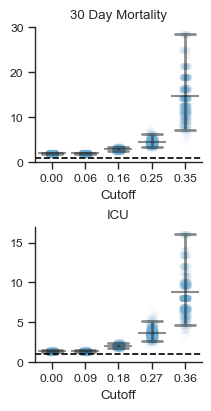

In [62]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(
    nrows=2,
    ncols=1,
    #width_ratios=[1, 1],
    constrained_layout=True,
    #sharey="row",
)

axs = axs.ravel()

sns.pointplot(
    data=mort_lr_df,
    x="Cutoff",
    y="LR+",
    hue="Cutoff",
    palette='dark:k',
    errorbar=("pi", 95),
    marker="_",
    markersize=20,
    markerfacecolor="k",
    color="k",
    capsize=.6,
    err_kws={"color": "k", "linewidth": 2},
    linewidth=2,
    legend=False,
    ax=axs[0],
    alpha=0.5
)

sns.stripplot(
    data=mort_lr_df,
    x="Cutoff",
    y="LR+",
    ax=axs[0],
    color="#6AAED6",
    linewidth=0,
    legend=False,
    alpha=0.02,
    zorder=1,

)

axs[0].set_xlabel("Cutoff\n30 Day Mortality")
axs[0].set_xticklabels(
    [f"{val:.2f}" for val in mort_lr_df['Cutoff']],
)

axs[0].axhline(y=1, linestyle='--', color='black')

#axs[3].set_ylim(0, 60)


sns.pointplot(
    data=icu_lr_df,
    x="Cutoff",
    y="LR+",
    hue="Cutoff",
    palette='dark:k',
    errorbar=("pi", 95),
    marker="_",
    markersize=20,
    markerfacecolor="k",
    color="k",
    capsize=.6,
    err_kws={"color": "k", "linewidth": 2},
    linewidth=2,
    legend=False,
    ax=axs[1],
    alpha=0.5
)

sns.stripplot(
    data=icu_lr_df,
    x="Cutoff",
    y="LR+",
    ax=axs[1],
    color="#6AAED6",
    linewidth=0,
    legend=False,
    alpha=0.02,
    zorder=1

)

axs[0].set_xlabel("Cutoff")
axs[0].set_title("30 Day Mortality")
axs[1].set_xlabel("Cutoff")
axs[1].set_title("ICU")

axs[1].set_xticklabels(
    [f"{val:.2f}" for val in icu_lr_df['Cutoff']],
)

axs[1].axhline(y=1, linestyle='--', color='black')

axs[0].set_ylabel("")
axs[0].set_ylim(0, 30)
axs[1].set_ylim(0, 17)
axs[1].set_ylabel("")

fig.set_size_inches(
    (2, 4)
)

fig.savefig("3_clinical_data_df_metrics.pdf", bbox_inches="tight", dpi=300, transparent=True)
